In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/57e24d88-fd01-4422-b8b5-d688d2296184___RS_HL 5401_newGGR.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/8665efd2-fa3d-45f8-b1c0-746c99fb7d1e___RS_HL 1924_new90degFlipLR.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/7948ada9-eabc-4cb7-a579-b73e938eb716___RS_HL 4185.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/468d3107-f09a-4f0d-8b9d-f08d7c49738f___RS_HL 1747_newGGR.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/00fc2ee5-729f-4757-8aeb-65c3355874f2___RS_HL 1864_new200degFlipTB.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/61b8a692-91d8-40f5-a4a4-4d910875a638___RS_HL 1966_new90degFlipLR.JPG
/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh/Potato___Healthy/

In [2]:
!pip install pandas pillow

In [3]:
!pip install pandas
!pip install opencv-python

In [4]:
!pip install tensorflow==2.12.0
!pip install keras

INFO: pip is looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: pip is still looking at multiple versions of jax to determine which version is compatible with other requirements. This could take a while.
INFO: This is taking longer than usual. You might need to provide the dependency resolver with stricter constraints to reduce runtime. See https://pip.pypa.io/warnings/backtracking for guidance. If you want to abort this run, press Ctrl + C.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 586.0/586.0 MB 2.9 MB/s eta 0:00:000:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 67.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 60.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 93.4 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 87.5 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 440.7/440

In [5]:
import numpy as np
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import cv2
import os
from tensorflow import keras
import glob as gb
import pandas as pd
from tensorflow.keras.preprocessing import image_dataset_from_directory

# ✅ Corrected imports
from tensorflow.keras.layers import RandomFlip, RandomRotation, Dense, Dropout, Flatten, Conv2D, MaxPool2D, LeakyReLU


In [7]:
from tensorflow.keras.preprocessing import image_dataset_from_directory
import tensorflow as tf

IMG_SIZE = (224, 224)  # ResNet-50 default resolution
directory = "/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh"
BATCH_SIZE = 64

# Load training dataset
train_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,  
    validation_split=0.1,
    subset='training',
    color_mode='rgb',
    seed=42
)

# Load validation dataset
validation_dataset = image_dataset_from_directory(
    directory,
    shuffle=True,
    labels='inferred',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,  
    validation_split=0.1,
    subset='validation',
    color_mode='rgb',
    seed=42
)

# Get number of classes
num_classes = len(train_dataset.class_names)
print("Number of classes:", num_classes)
print("Class names:", train_dataset.class_names)


Found 8286 files belonging to 3 classes.
Using 7458 files for training.
Found 8286 files belonging to 3 classes.
Using 828 files for validation.
Number of classes: 3
Class names: ['Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight']


In [8]:
class_names = train_dataset.class_names
class_names

['Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight']

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1765: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  order = pd.unique(vector)


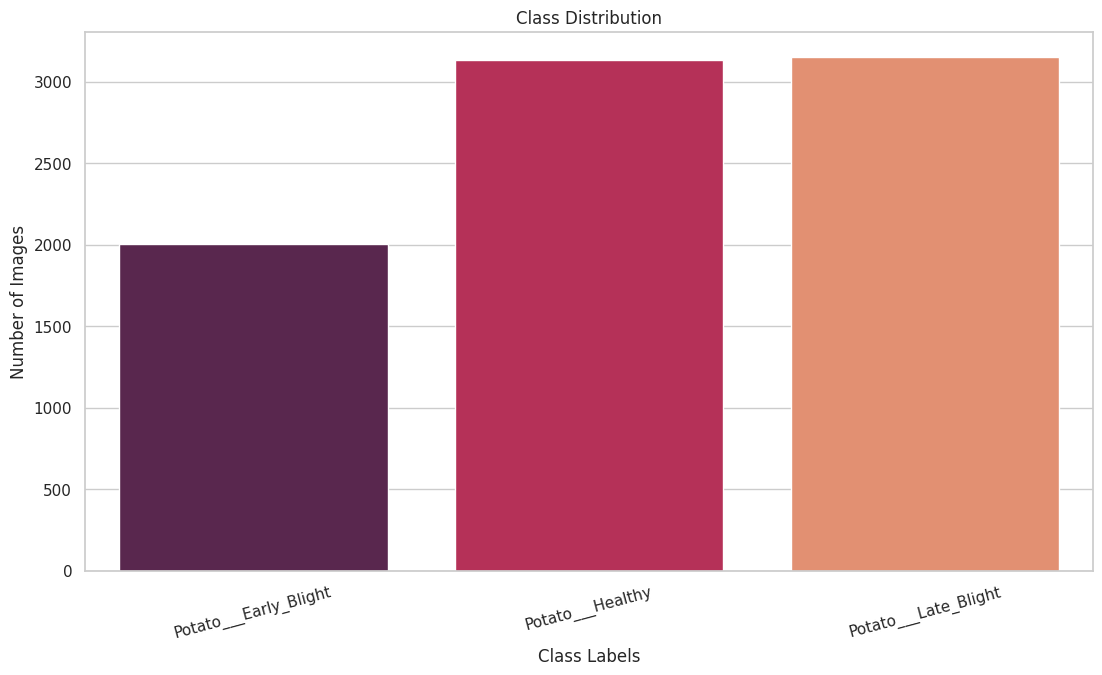

In [9]:
import os
import glob as gb
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Define the path to the dataset directory
directory = '/kaggle/input/potato-leaf/Potato Leaf Diseases Dataset From Bangladesh'  # 🔁 Replace with your actual directory

# Initialize list for storing data imbalance info
Data_imbalance = []

# Loop through each class folder and count the number of images
for folder in os.listdir(directory):
    files = gb.glob(pathname=os.path.join(directory, folder, "*.*"))
    Data_imbalance.append(len(files))

# Class labels (make sure they match actual folder names)
class_labels = ['Potato___Early_Blight', 'Potato___Healthy', 'Potato___Late_Blight']

# Plot data imbalance
plt.figure(figsize=(13, 7))
sns.barplot(
    x=class_labels,
    y=Data_imbalance,
    palette="rocket"
)
plt.title("Class Distribution")
plt.xlabel("Class Labels")
plt.ylabel("Number of Images")
plt.xticks(rotation=15)
plt.show()


In [11]:
total = 0
for i in range(0,len(Data_imbalance)) :
    total +=Data_imbalance[i]

weight_for_0 = (1 / Data_imbalance[0]) * (total / 4.0)
weight_for_1 = (1 / Data_imbalance[1]) * (total / 4.0)
weight_for_2 = (1 / Data_imbalance[2]) * (total / 4.0)

class_weight = {0: weight_for_0, 1: weight_for_1, 2: weight_for_2}

print('Weight for class 0: {:.2f}'.format(weight_for_0))
print('Weight for class 1: {:.2f}'.format(weight_for_1))
print('Weight for class 2: {:.2f}'.format(weight_for_2))

Weight for class 0: 1.03
Weight for class 1: 0.66
Weight for class 2: 0.66


In [12]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomHeight(0.2),
  tf.keras.layers.RandomWidth(0.2),
])

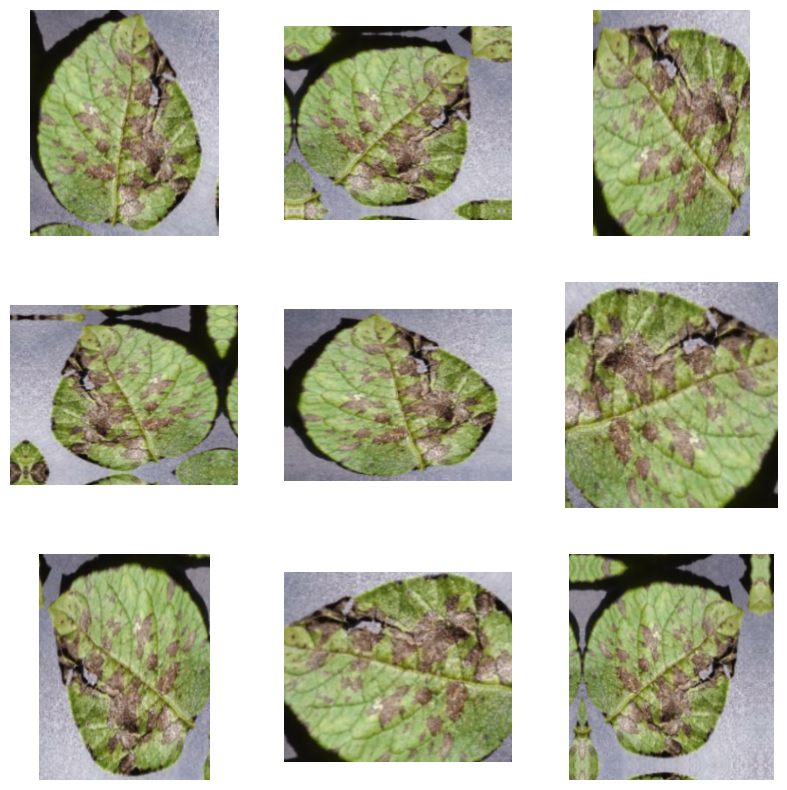

In [13]:
for image, _ in train_dataset.take(1):
    plt.figure(figsize=(10, 10))
    first_image = image[0]
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        augmented_image = data_augmentation(tf.expand_dims(first_image, 0))
        plt.imshow(augmented_image[0] / 255)
        plt.axis('off')

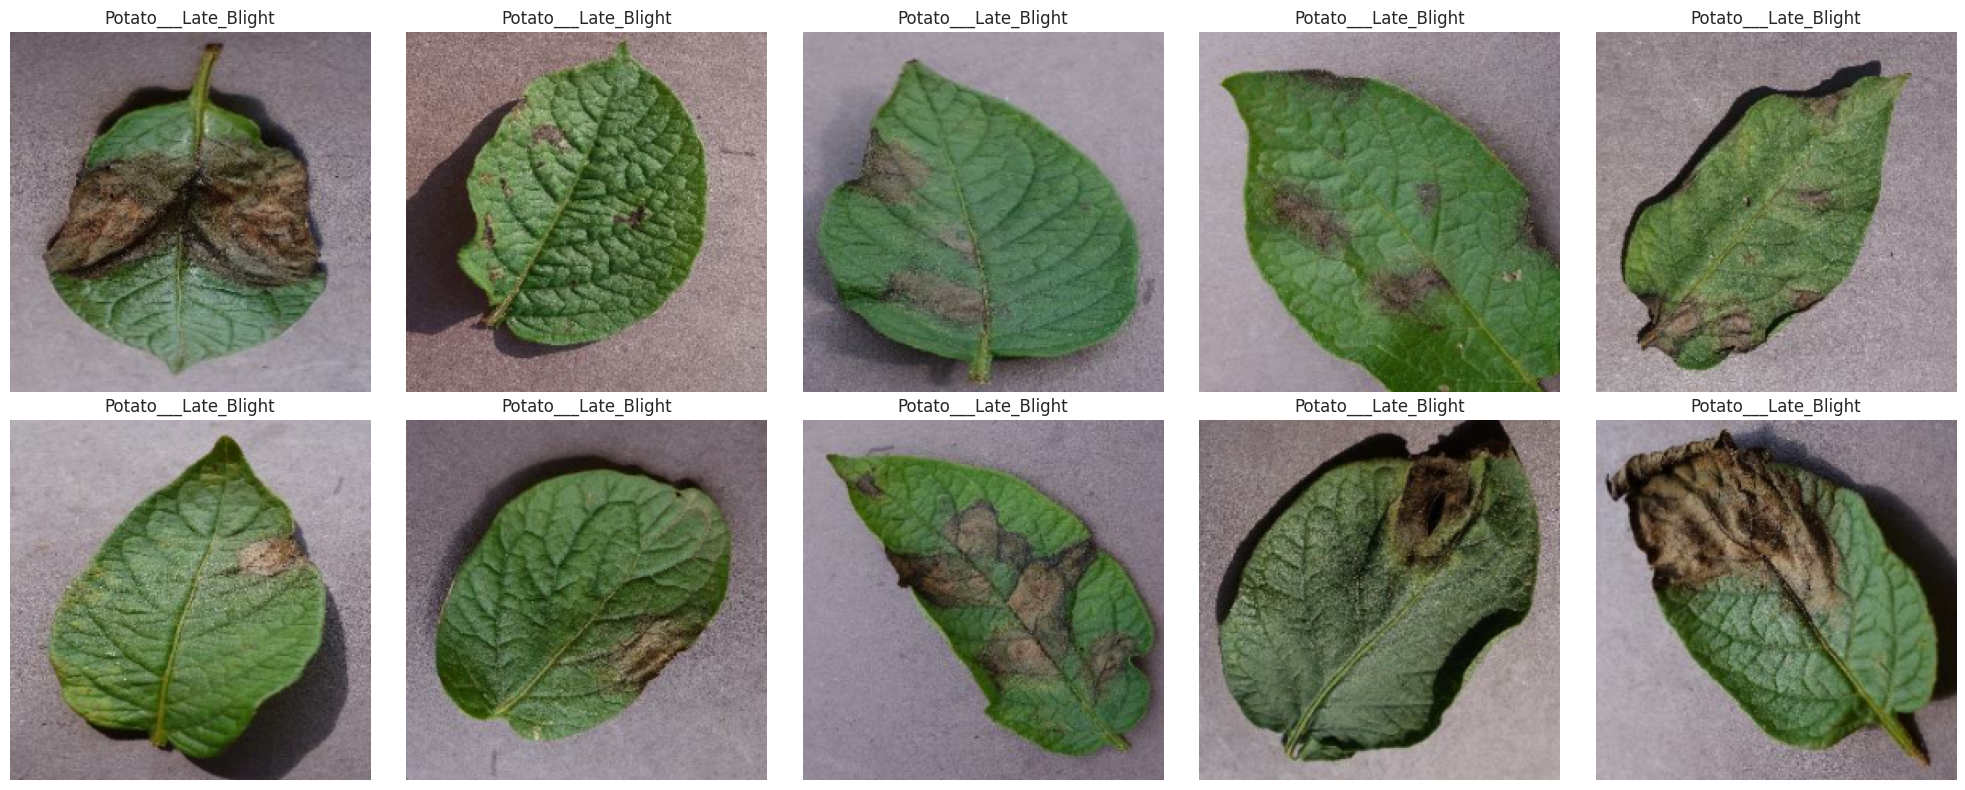

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# Initialize lists to store images
Potato___Early_Blight = []
Potato___Healthy = []
Potato___Late_Blight = []

# Loop through a batch of images
for images, labels in train_dataset.take(1):
    labels = labels.numpy()  # convert tensor to numpy array
    for i in range(len(labels)):  # use actual batch size
        label_name = class_names[labels[i]]
        if label_name == "Potato___Early_Blight":
            Potato___Early_Blight.append(images[i].numpy().astype("uint8"))
        elif label_name == "Potato___Healthy":
            Potato___Healthy.append(images[i].numpy().astype("uint8"))
        elif label_name == "Potato___Late_Blight":
            Potato___Late_Blight.append(images[i].numpy().astype("uint8"))

# Display 10 images from Potato___Late_Blight class
for i in range(min(10, len(Potato___Late_Blight))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(Potato___Late_Blight[i])
    plt.axis("off")
    plt.title("Potato___Late_Blight")

plt.tight_layout()
plt.show()


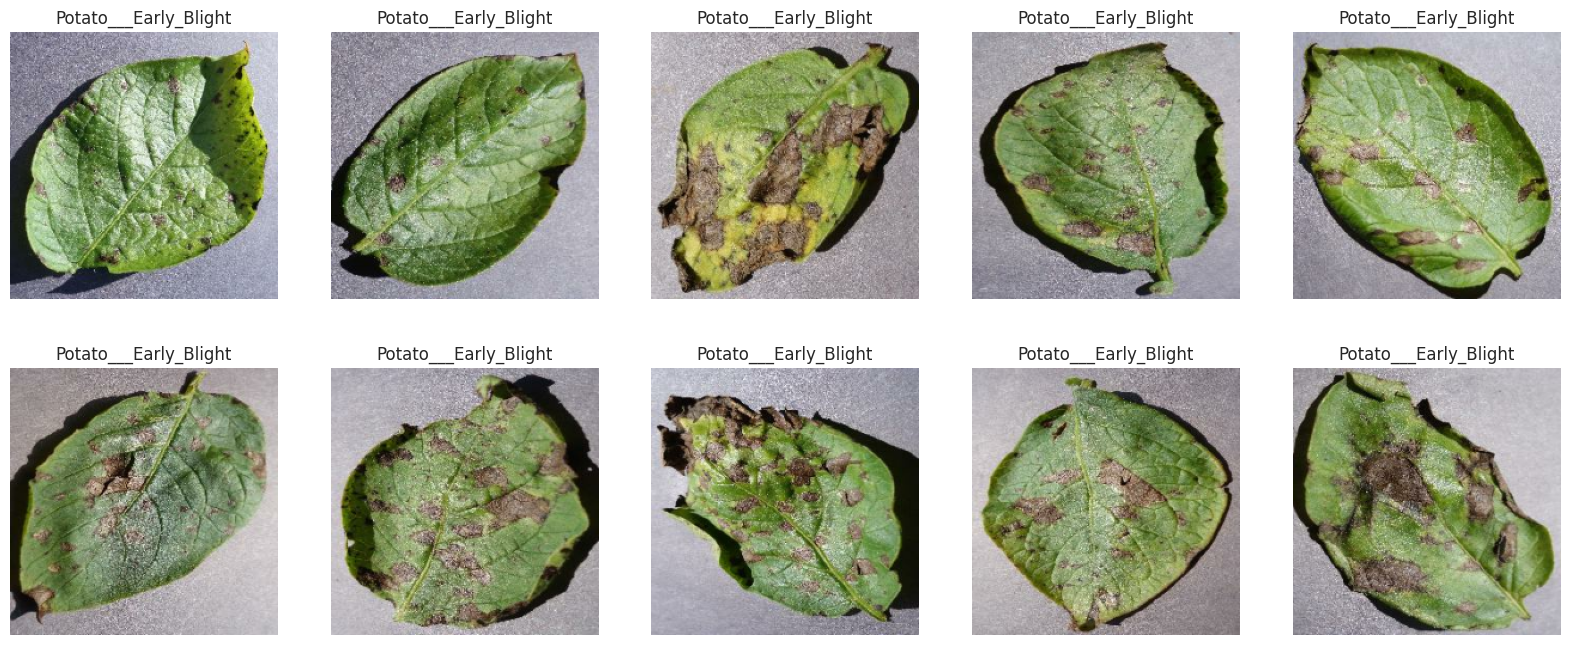

In [19]:
plt.figure(figsize=(20,8))
for i in range(min(10, len(Potato___Early_Blight))): # Changed to display up to 10 or the available images
    plt.subplot(2,5,i+1)
    plt.imshow(Potato___Early_Blight[i])
    plt.axis("off")
    plt.title("Potato___Early_Blight")

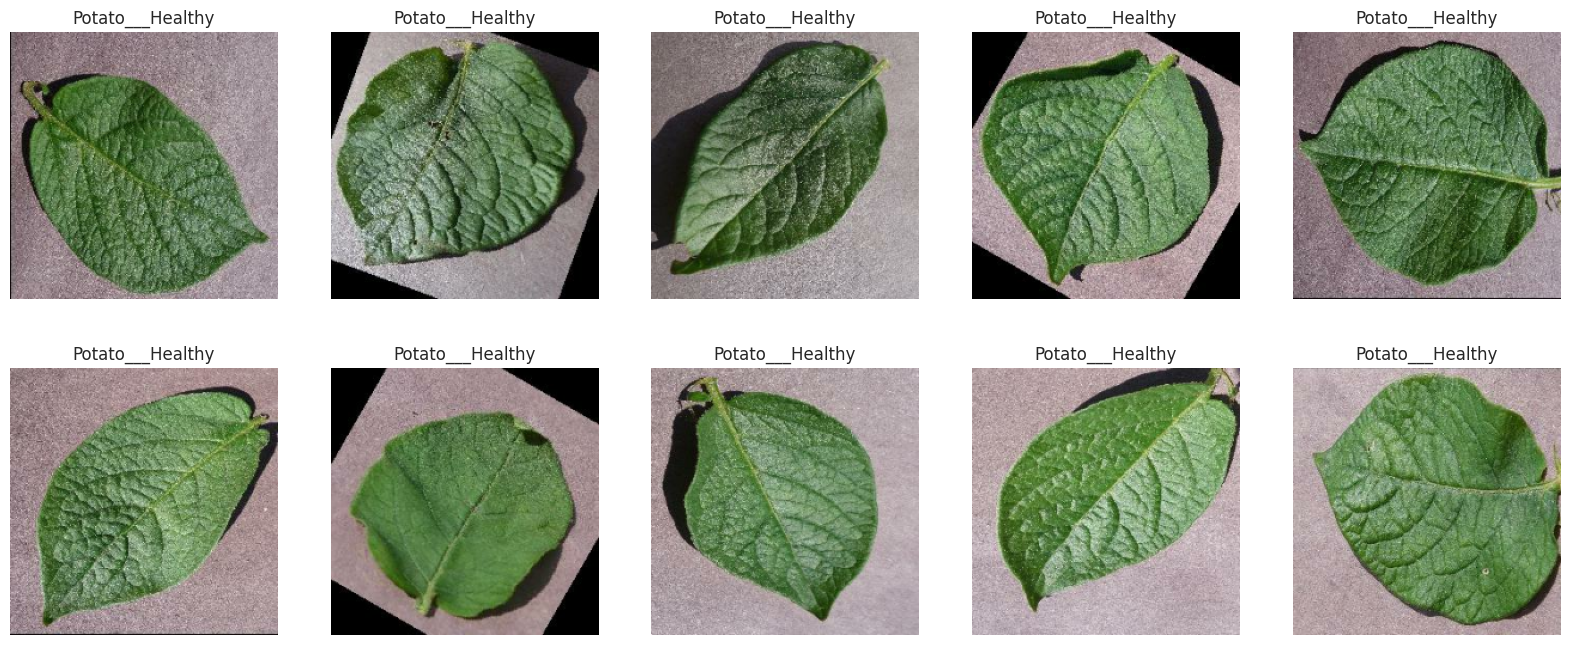

In [20]:
plt.figure(figsize=(20,8))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(Potato___Healthy[i])
    plt.axis("off")
    plt.title("Potato___Healthy")

In [21]:
import tensorflow as tf

# Enable automatic prefetching for better performance
AUTOTUNE = tf.data.AUTOTUNE  # Updated to tf.data.AUTOTUNE (latest TensorFlow versions)

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)  # Apply to validation dataset too

In [22]:
from tensorflow.keras.layers import Rescaling

normalization_layer = Rescaling(1./255)

train_dataset = train_dataset.map(lambda x, y: (normalization_layer(x), y))
validation_dataset = validation_dataset.map(lambda x, y: (normalization_layer(x), y))


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPool2D, Dropout, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

model = Sequential(name="sequential")

# Add layers
model.add(Conv2D(32, 3, padding="same", activation="relu", input_shape=(224, 224, 3)))
model.add(MaxPool2D())
model.add(Conv2D(32, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Conv2D(32, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Conv2D(64, 3, padding="same", activation="relu"))
model.add(MaxPool2D())
model.add(Dropout(0.4))
model.add(Flatten())

model.add(Dense(128, activation="relu"))

# Use dynamic num_classes instead of hardcoded 3
model.add(Dense(num_classes, activation="softmax"))

model.summary()

# Compile the model with a lower learning rate to avoid NaN loss
model.compile(
    optimizer=Adam(learning_rate=1e-4),  # or try 1e-5 if NaNs persist
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Early stopping callback (optional)
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)


Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 32)      9248      
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 32)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 32)        9248      
                                                                 
 max_pooling2d_2 (MaxPooling  (None, 28, 28, 32)       0

In [24]:
EPOCHS = 10

# Remove class_weight for now (define if needed later)
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    callbacks=[early_stopping]  # add early stopping if you want
)

# Evaluate the model on the validation dataset
test_loss, test_accuracy = model.evaluate(validation_dataset)

print(f"\n✅ Testing Accuracy: {test_accuracy * 100:.2f}%")
print(f"🧪 Testing Loss: {test_loss:.4f}")


Epoch 1/10
117/117 [==============================] - 307s 3s/step - loss: 0.8455 - accuracy: 0.6132 - val_loss: 0.4827 - val_accuracy: 0.8708
Epoch 2/10
117/117 [==============================] - 305s 3s/step - loss: 0.4043 - accuracy: 0.8656 - val_loss: 0.3194 - val_accuracy: 0.9094
Epoch 3/10
117/117 [==============================] - 309s 3s/step - loss: 0.2131 - accuracy: 0.9283 - val_loss: 0.2200 - val_accuracy: 0.9251
Epoch 5/10
117/117 [==============================] - 314s 3s/step - loss: 0.1742 - accuracy: 0.9362 - val_loss: 0.1424 - val_accuracy: 0.9541
Epoch 6/10
117/117 [==============================] - 315s 3s/step - loss: 0.1366 - accuracy: 0.9520 - val_loss: 0.1407 - val_accuracy: 0.9541
Epoch 7/10
117/117 [==============================] - 312s 3s/step - loss: 0.0958 - accuracy: 0.9678 - val_loss: 0.1552 - val_accuracy: 0.9420
Epoch 8/10
117/117 [==============================] - 310s 3s/step - loss: 0.0789 - accuracy: 0.9751 - val_loss: 0.0832 - val_accuracy: 0.9674

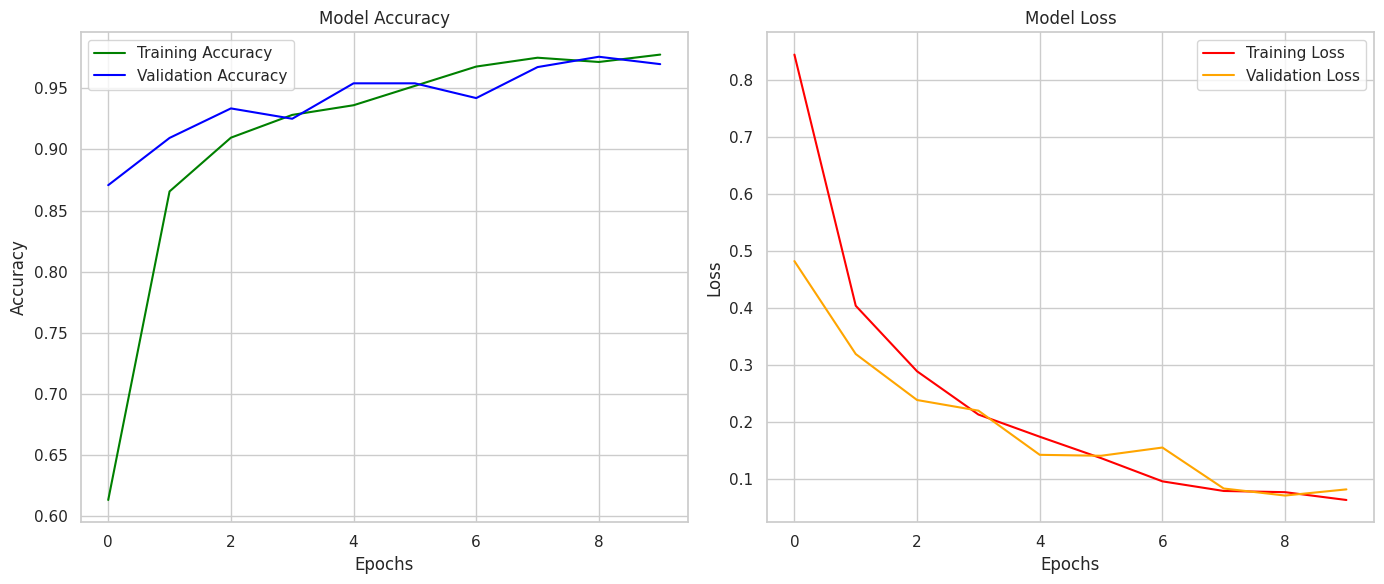

In [25]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='blue')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

2/2 [==============================] - 1s 286ms/step


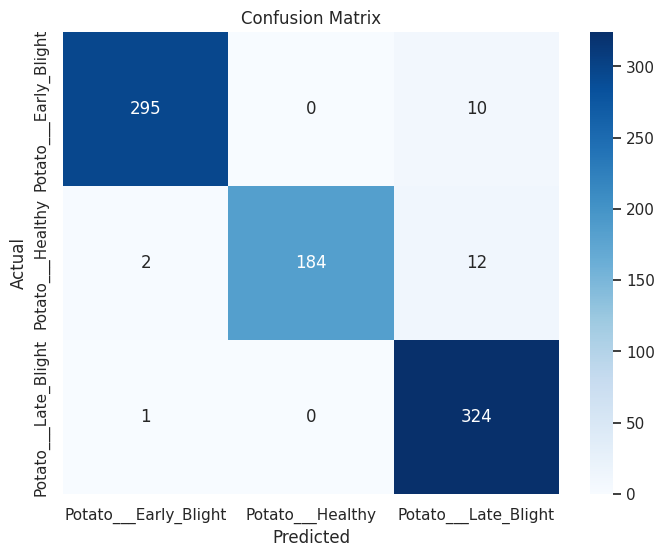

In [26]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Get true labels and predictions
y_true = []
y_pred = []

for images, labels in validation_dataset:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [27]:
# Classification Report
report = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n")
print(report)

Classification Report:

                       precision    recall  f1-score   support

Potato___Early_Blight       0.99      0.97      0.98       305
     Potato___Healthy       1.00      0.93      0.96       198
 Potato___Late_Blight       0.94      1.00      0.97       325

             accuracy                           0.97       828
            macro avg       0.98      0.96      0.97       828
         weighted avg       0.97      0.97      0.97       828

